In [131]:
# Uninstall the current version of Numpy
!pip uninstall -y numpy

# Install numpy version 1.26.4
!pip install numpy==1.26.4

# Install surprise library now
!pip install scikit-surprise --prefer-binary


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)


In [132]:
import numpy as np

In [133]:
print(f"NumPy version: {np.__version__}")

NumPy version: 1.26.4


In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
netflix_dataset = pd.read_csv(r'C:\Users\SAMARTH\Desktop\ML projects\combined_data_1.txt',header = None, names = ['Cust_Id', 'Rating'], usecols = [0,1])

In [136]:
netflix_dataset.head()

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [137]:
netflix_dataset.shape

(24058263, 2)

In [138]:
netflix_dataset.dtypes #here we have object dtype of Cust_Id because movie id is present in this column which has ':' in it 

Cust_Id     object
Rating     float64
dtype: object

In [139]:
#the movie cannot rate itself right, obviously so the movie id will have blank NaN value in the ratings column

In [140]:
netflix_dataset.isna().sum() #these null values are because of the movie id in the Cust_Id column which does not as any ratings

Cust_Id       0
Rating     4499
dtype: int64

In [141]:
#now finding out the count of movie id in my dataset which will be equal to the no. of null values in my rating coolumn 
#movie count =No. of NaN values in Rating column
movie_count=netflix_dataset.isna().sum()
movie_count=movie_count['Rating']
print("Movie Count is : ",movie_count)

Movie Count is :  4499


In [142]:
#Finding the unique no. of customers in our dataset
customer_count=netflix_dataset['Cust_Id'].nunique() #unique() returns unique values and nunique() returns the count
print(customer_count)

475257


In [143]:
#the above customer id count contains movie id also so substracting it to get the actual cust id count
actual_custid_count=customer_count-movie_count
print("The actual number of unique customers present in out dataset are :",actual_custid_count)

The actual number of unique customers present in out dataset are : 470758


In [144]:
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [145]:
#finding the total number of ratings given my customers for all movies combined
rating_count=netflix_dataset['Cust_Id'].count()-movie_count
print("Total no. of ratings given by all customers are : ",rating_count)

Total no. of ratings given by all customers are :  24053764


In [146]:
stars=netflix_dataset.groupby('Rating')['Rating'].agg(['count'])
print(stars)

          count
Rating         
1.0     1118186
2.0     2439073
3.0     6904181
4.0     8085741
5.0     5506583


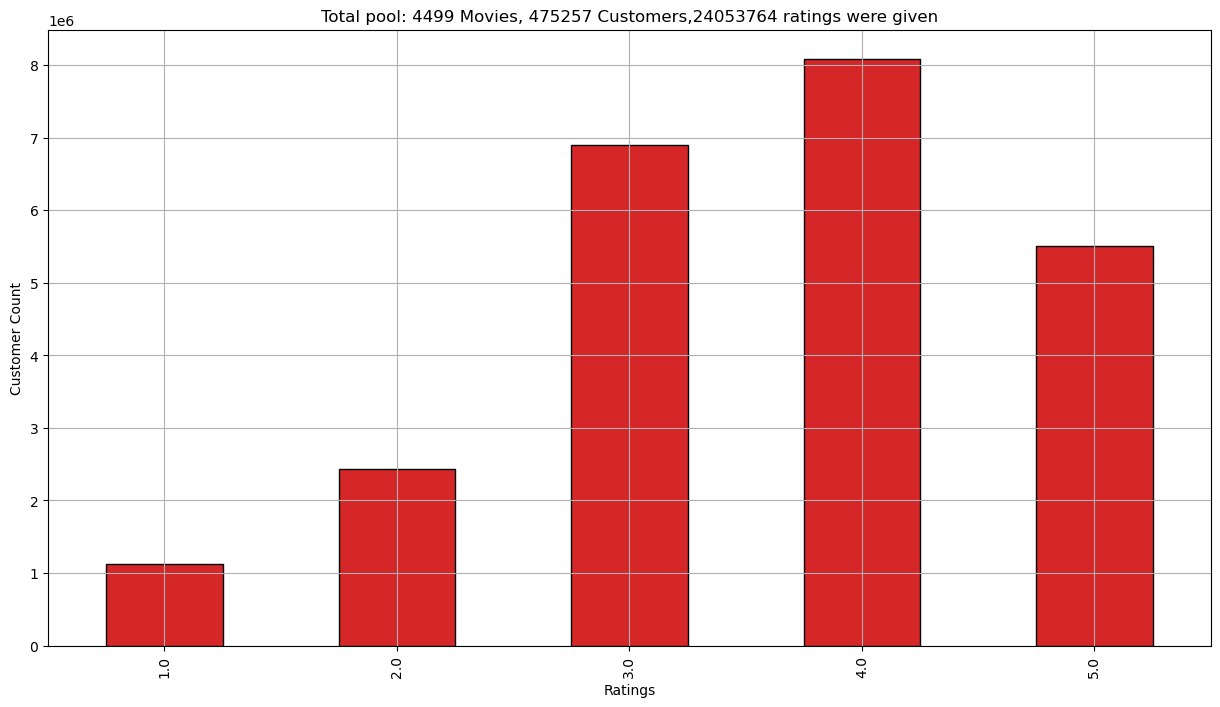

In [147]:
stars.plot(kind='bar',legend=False,figsize=(15,8),color='tab:red',edgecolor='black')
plt.title(f'Total pool: {movie_count} Movies, {customer_count} Customers,{rating_count} ratings were given')
plt.ylabel("Customer Count")
plt.xlabel("Ratings")
plt.grid(True)

In [148]:
netflix_dataset.head(100)

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
95,1245406,4.0
96,1834590,3.0
97,593225,3.0
98,1011918,4.0


In [149]:
#making a clear dataframe having movie_id
movie_id=None
movie_np=[]
#iterating over the dataframe rows
for i in netflix_dataset['Cust_Id']:
    if ':' in i:
        #updating the current movie id
        movie_id=int(i.replace(':',''))
    movie_np.append(movie_id)


In [150]:
#adding that dataframe as a separate column in our dataset
netflix_dataset["Movie_Id"]=movie_np
netflix_dataset.head(5)

,Cust_Id,Rating,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1


In [151]:
#keeping only the rows where rating column is not null
netflix_dataset=netflix_dataset[netflix_dataset['Rating'].notna()]

In [152]:
#see once
netflix_dataset

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [153]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [154]:
 netflix_dataset.isna().sum() # see null values are gone

Cust_Id     0
Rating      0
Movie_Id    0
dtype: int64

In [155]:
netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)

C:\Users\SAMARTH\AppData\Local\Temp\ipykernel_15252\358752458.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)


In [156]:
netflix_dataset.info()


<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int32  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int32(1), int64(1)
memory usage: 642.3 MB


In [157]:
#Pre-Filtering
#now we will remove all users that have rated less movies
#Also those movies that are rated less in number
dataset_movie_summary=netflix_dataset.groupby('Movie_Id')['Rating'].agg(['count'])

In [158]:
dataset_movie_summary

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [159]:
#now we want those movies which are important or that are hit and want to remove flop movies
#so deciding a benchmark that till this much ratings given i will keep else i will drop that movie
movie_benchmark=round(dataset_movie_summary['count'].quantile(0.6),0)
movie_benchmark #1799 is my bench mark this much ratings should be given to movie

908.0

In [160]:
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count'] < movie_benchmark].index
drop_movie_list #these contains those movies which have less benchmark 

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [161]:
len(drop_movie_list) #these much movies we need to drop

2699

In [162]:
#Movies left will be
left_movies=len(dataset_movie_summary)-len(drop_movie_list)
left_movies

1800

In [163]:
#now removinig the users that are inactive 
dataset_cust_summary=netflix_dataset.groupby('Cust_Id')['Rating'].agg(['count'])
dataset_cust_summary

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [164]:
#now creating the benchmark for customers we will keep only those customers which are loyal and has rated multiple times
cust_benchmark=round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark #atleast 36 ratings must be given by customer then only we will keep that customer

36.0

In [165]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count'] < cust_benchmark].index 
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int32', name='Cust_Id', length=282042)

In [166]:
len(drop_cust_list) #these many are the inactive customers in out dataset

282042

In [167]:
netflix_dataset = netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]
netflix_dataset = netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_list)]

print("After Deleting these above data my shape of dataset is : {}".format(netflix_dataset.shape))

After Deleting these above data my shape of dataset is : (19695836, 3)


In [168]:
# '~' is used above which is a negation symbol is basically flips the condition above condition was store the data in my original dataset
# which is in drop_movie/cust_list so to reverse the decision we are using this condition 
#flips it: True becomes False and vice versa, so now it means "keep rows whose movie is NOT in the drop list."

In [169]:
netflix_dataset #this is ur fully cleaned data

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


# Model Building Starts Here


In [170]:
df_title = pd.read_csv(r"C:\Users\SAMARTH\Desktop\ML projects\movie_titles _1_.csv", encoding='latin', header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name'])

In [171]:
df_title.head()

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [172]:
df_title.shape

(17770, 3)

In [173]:
from surprise import Reader,Dataset,SVD #reader reads the format/order of dataset
from surprise.model_selection import cross_validate

In [174]:
reader=Reader() #creating object for reader 


In [175]:
#now we will work with top 100k rows for quick runtime
data = Dataset.load_from_df(netflix_dataset[['Cust_Id','Movie_Id','Rating']].sample(100000, random_state=42), reader)

In [176]:
model=SVD() #Creating an svd model

In [177]:
cross_validate(model,data,measures=['RMSE'],cv=3) #training the model train and test total 3 times also finds root mean square 

{'test_rmse': array([1.0048696 , 1.00921746, 1.00299341]),
 'fit_time': (2.48881459236145, 2.3830270767211914, 2.6919219493865967),
 'test_time': (0.5620036125183105, 0.5370073318481445, 0.536104679107666)}

In [178]:
trainset = data.build_full_trainset()
model = SVD()
model.fit(trainset)

### **Using model for making recommendation for a specific user**

In [179]:
#filtering dataset for a random user selected to make recommendation to that user 
user_ratings=netflix_dataset[netflix_dataset['Cust_Id']==712664]
user_ratings

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
31456,712664,4.0,18
46415,712664,3.0,26
290337,712664,1.0,77
303936,712664,1.0,78
...,...,...,...
23499778,712664,2.0,4393
23546479,712664,4.0,4402
23649414,712664,3.0,4432
23836676,712664,4.0,4465


In [180]:
#finding the no. of unique ratings given by this user
movies_rated_by_user=user_ratings['Movie_Id'].nunique()
print(f"Number of unique movies rated by the user is {movies_rated_by_user}")  

Number of unique movies rated by the user is 383


In [181]:
copy_data_for_user=df_title.copy() #making a copy for each indivisual customer for the recommendation
copy_data_for_user

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [182]:
clean_copy_data_for_user=copy_data_for_user[~copy_data_for_user['Movie_Id'].isin(drop_movie_list)]
clean_copy_data_for_user #removed all the low rated flop movies and kept only hit movies to recommend our user

,Movie_Id,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [183]:
clean_copy_data_for_user['Estimate_Score']=clean_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(712664, x).est)
# predict the score (rating) that a user (with 712664 user ID ) might give to a list of movies.
# core thing

C:\Users\SAMARTH\AppData\Local\Temp\ipykernel_15252\953400862.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_copy_data_for_user['Estimate_Score']=clean_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(712664, x).est)


In [184]:
clean_copy_data_for_user

,Movie_Id,Year,Name,Estimate_Score
2,3,1997.0,Character,3.579075
4,5,2004.0,The Rise and Fall of ECW,3.895888
5,6,1997.0,Sick,3.504272
7,8,2004.0,What the #$*! Do We Know!?,3.272369
15,16,1996.0,Screamers,3.424349
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.597740
17766,17767,2004.0,Fidel Castro: American Experience,3.597740
17767,17768,2000.0,Epoch,3.597740
17768,17769,2003.0,The Company,3.597740


In [185]:
clean_copy_data_for_user.sort_values('Estimate_Score', ascending=False) # Descending order  estimated score displays top movies

,Movie_Id,Year,Name,Estimate_Score
3455,3456,2004.0,Lost: Season 1,4.561835
2101,2102,1994.0,The Simpsons: Season 6,4.542105
3443,3444,2004.0,Family Guy: Freakin' Sweet Collection,4.541331
2161,2162,2000.0,CSI: Season 1,4.508333
3045,3046,1990.0,The Simpsons: Treehouse of Horror,4.480031
...,...,...,...,...
3504,3505,2001.0,Freddy Got Fingered,2.461200
288,289,1998.0,The Avengers,2.450260
224,225,2004.0,The Cookout,2.410743
4254,4255,2002.0,Gerry,2.188525


In [186]:
top_5_movies=clean_copy_data_for_user.sort_values('Estimate_Score',ascending=False).head() #sorting the top 5 movies :)

In [187]:
top_5_movies

,Movie_Id,Year,Name,Estimate_Score
3455,3456,2004.0,Lost: Season 1,4.561835
2101,2102,1994.0,The Simpsons: Season 6,4.542105
3443,3444,2004.0,Family Guy: Freakin' Sweet Collection,4.541331
2161,2162,2000.0,CSI: Season 1,4.508333
3045,3046,1990.0,The Simpsons: Treehouse of Horror,4.480031
